# Финальный проект

**Тема**: сравнение методов понижения размерности и кластеризации на датасете `python_learning_exam_performance.csv` с анализом устойчивости и интерпретацией кластеров.

**Датасет**: 3000 студентов, 15 столбцов.  
**Подход**: preprocessing -> DR (PCA, Isomap, t-SNE) -> clustering (KMeans, Agglomerative, GMM, DBSCAN) -> метрики -> устойчивость -> интерпретация кластеров.

`passed_exam` используется только как внешняя проверка качества кластеризации. В признаки для кластеризации он не входит.


In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = [12, 8]
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


Среда готова. Для сравнения берем три метода DR и четыре алгоритма кластеризации, чтобы отдельно посмотреть на геометрию данных, связь с `passed_exam` и устойчивость результатов.


In [2]:
df = pd.read_csv("python_learning_exam_performance.csv")
df["prior_programming_experience"] = df["prior_programming_experience"].fillna("Unknown")

print(f"Форма датасета: {df.shape}")
print(f"Доля сдавших экзамен: {df['passed_exam'].mean():.2%}")
print("\nРаспределение целевой переменной:")
print(df["passed_exam"].value_counts().sort_index())
print("\nПропуски:")
print(df.isna().sum())

display(df.head())


Форма датасета: (3000, 15)
Доля сдавших экзамен: 17.73%

Распределение целевой переменной:
passed_exam
0    2468
1     532
Name: count, dtype: int64

Пропуски:
student_id                           0
age                                  0
country                              0
prior_programming_experience         0
weeks_in_course                      0
hours_spent_learning_per_week        0
practice_problems_solved             0
projects_completed                   0
tutorial_videos_watched              0
uses_kaggle                          0
participates_in_discussion_forums    0
debugging_sessions_per_week          0
self_reported_confidence_python      0
final_exam_score                     0
passed_exam                          0
dtype: int64


,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,Unknown,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,Unknown,3,3.5,62,1,47,1,0,3,7,24.8,0


В датасете 3000 наблюдений и 15 столбцов. После замены пропусков в `prior_programming_experience` на `Unknown` пропусков не остается. Доля сдавших экзамен составляет 17.7%, поэтому внешний контроль качества кластеров нужно читать с учетом сильного дисбаланса классов.


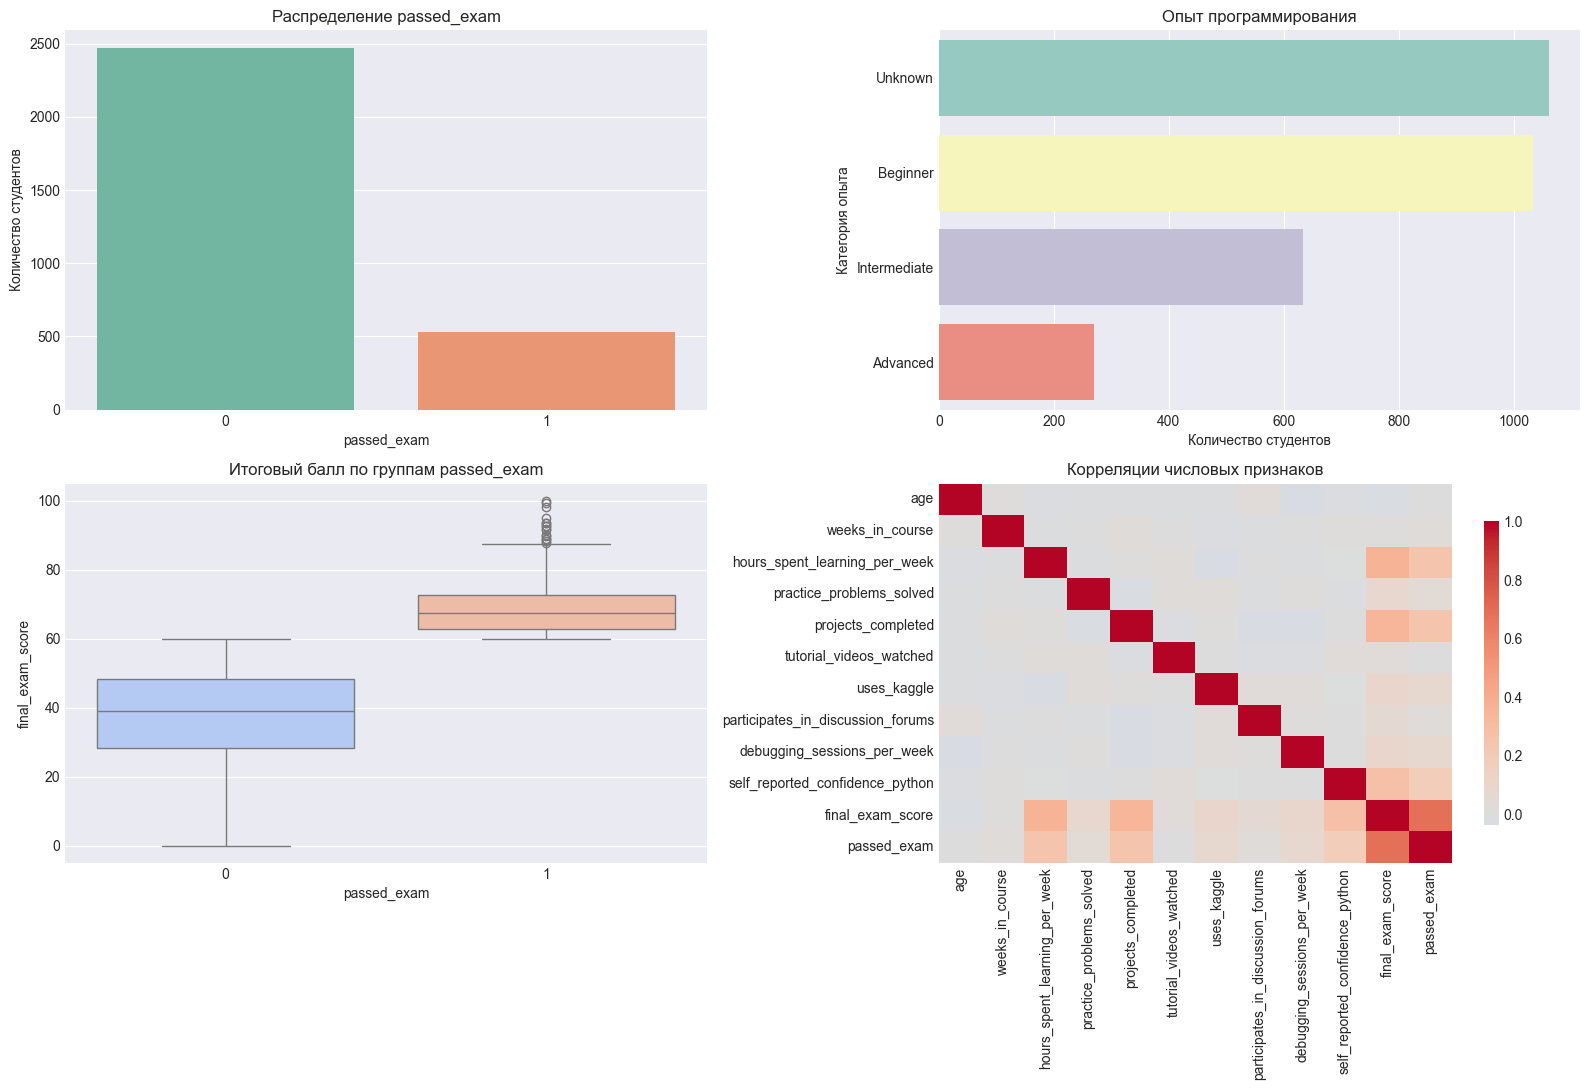

Топ корреляций с final_exam_score:


,corr_with_final_exam_score
final_exam_score,1.000000
passed_exam,0.686611
hours_spent_learning_per_week,0.365296
projects_completed,0.352102
self_reported_confidence_python,0.282321
uses_kaggle,0.100349
debugging_sessions_per_week,0.092876
practice_problems_solved,0.081669


In [3]:
numeric_df = df.select_dtypes(include=["number"])
corr_with_exam = numeric_df.corr(numeric_only=True)["final_exam_score"].sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df, x="passed_exam", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Распределение passed_exam")
axes[0, 0].set_xlabel("passed_exam")
axes[0, 0].set_ylabel("Количество студентов")

exp_order = df["prior_programming_experience"].value_counts().index
sns.countplot(
    data=df,
    y="prior_programming_experience",
    order=exp_order,
    ax=axes[0, 1],
    palette="Set3",
)
axes[0, 1].set_title("Опыт программирования")
axes[0, 1].set_xlabel("Количество студентов")
axes[0, 1].set_ylabel("Категория опыта")

sns.boxplot(
    data=df,
    x="passed_exam",
    y="final_exam_score",
    ax=axes[1, 0],
    palette="coolwarm",
)
axes[1, 0].set_title("Итоговый балл по группам passed_exam")
axes[1, 0].set_xlabel("passed_exam")
axes[1, 0].set_ylabel("final_exam_score")

corr_plot = numeric_df.drop(columns=["student_id"]).corr(numeric_only=True)
sns.heatmap(
    corr_plot,
    cmap="coolwarm",
    center=0,
    ax=axes[1, 1],
    cbar_kws={"shrink": 0.8},
)
axes[1, 1].set_title("Корреляции числовых признаков")

plt.tight_layout()
plt.show()

print("Топ корреляций с final_exam_score:")
display(corr_with_exam.to_frame("corr_with_final_exam_score").head(8))


Класс `passed_exam=1` заметно меньше по размеру, чем `passed_exam=0`, что подтверждает дисбаланс. Самые частые категории опыта: `Unknown` (1062), `Beginner` (1034) и `Intermediate` (634). По числовым связям сильнее всего с `final_exam_score` связаны `hours_spent_learning_per_week` (0.365), `projects_completed` (0.352) и `self_reported_confidence_python` (0.282). Это уже намекает, что кластеры могут разделяться по вовлеченности и уверенности.


In [4]:
feature_cols = [col for col in df.columns if col not in ["student_id", "passed_exam"]]
numeric_cols = df[feature_cols].select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in feature_cols if col not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_cols,
        ),
    ]
)

X = preprocessor.fit_transform(df[feature_cols])
y = df["passed_exam"].to_numpy()
encoded_feature_names = preprocessor.get_feature_names_out()

print(f"Числовых признаков: {len(numeric_cols)}")
print(f"Категориальных признаков: {len(categorical_cols)}")
print(f"Размер матрицы после кодирования: {X.shape}")
print("\nПервые признаки после трансформации:")
print(encoded_feature_names[:12])


Числовых признаков: 11
Категориальных признаков: 2
Размер матрицы после кодирования: (3000, 25)

Первые признаки после трансформации:
['num__age' 'num__weeks_in_course' 'num__hours_spent_learning_per_week'
 'num__practice_problems_solved' 'num__projects_completed'
 'num__tutorial_videos_watched' 'num__uses_kaggle'
 'num__participates_in_discussion_forums'
 'num__debugging_sessions_per_week' 'num__self_reported_confidence_python'
 'num__final_exam_score' 'cat__country_Bangladesh']


 После стандартизации числовых признаков и one-hot кодирования категориальных получаем матрицу размера 3000 x 25. Это хороший компромисс: модель видит и учебную активность, и опыт, и страну студента, но при этом размерность все еще удобна для DR.


,k,silhouette,calinski_harabasz,davies_bouldin,ARI_passed_exam
0,2,0.0800,276.1044,3.2552,0.1710
1,3,0.0723,233.2729,3.0529,0.0317
2,4,0.0660,203.8531,2.8827,0.1213
3,5,0.0764,182.8673,2.9599,0.0699
4,6,0.0687,164.3980,3.0366,0.0141


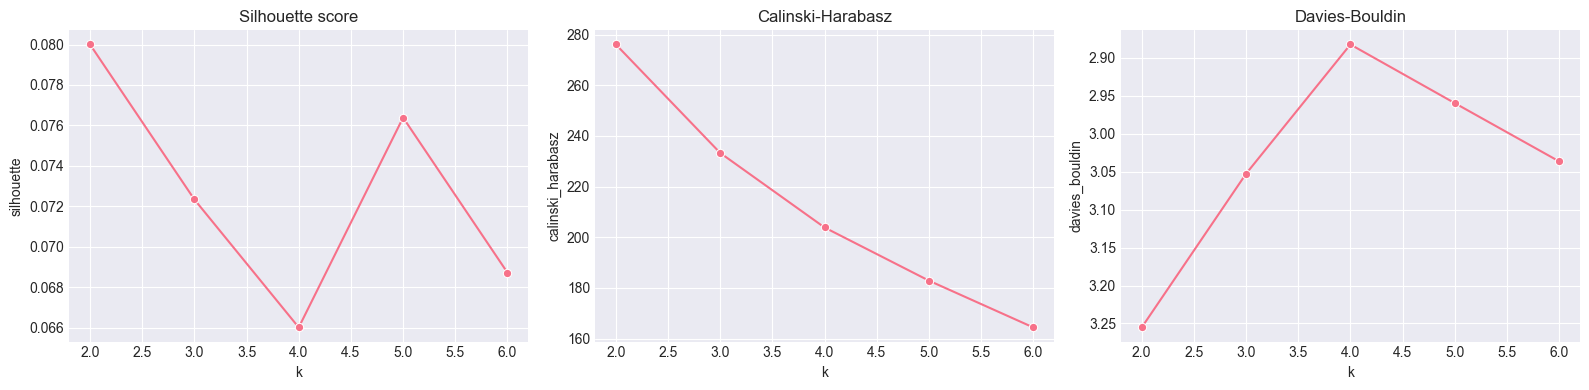

In [5]:
k_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X)
    k_rows.append(
        {
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "ARI_passed_exam": adjusted_rand_score(y, labels),
        }
    )

k_results = pd.DataFrame(k_rows)
display(k_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.lineplot(data=k_results, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=k_results, x="k", y="calinski_harabasz", marker="o", ax=axes[1])
sns.lineplot(data=k_results, x="k", y="davies_bouldin", marker="o", ax=axes[2])

axes[0].set_title("Silhouette score")
axes[1].set_title("Calinski-Harabasz")
axes[2].set_title("Davies-Bouldin")
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()


По `silhouette` лучшим оказался вариант с `k=2` (`0.080`), и именно при `k=2` получаем наибольший ARI относительно `passed_exam` (`0.171`). Поэтому для KMeans, Agglomerative и GMM дальше используем два кластера: это самый разумный базовый сценарий для этого датасета.


,method,runtime_sec
0,PCA,0.00
1,Isomap,1.77
2,t-SNE,7.15


PCA explained_variance_ratio_: [0.1309 0.0859]
PCA cumulative variance: 0.2168


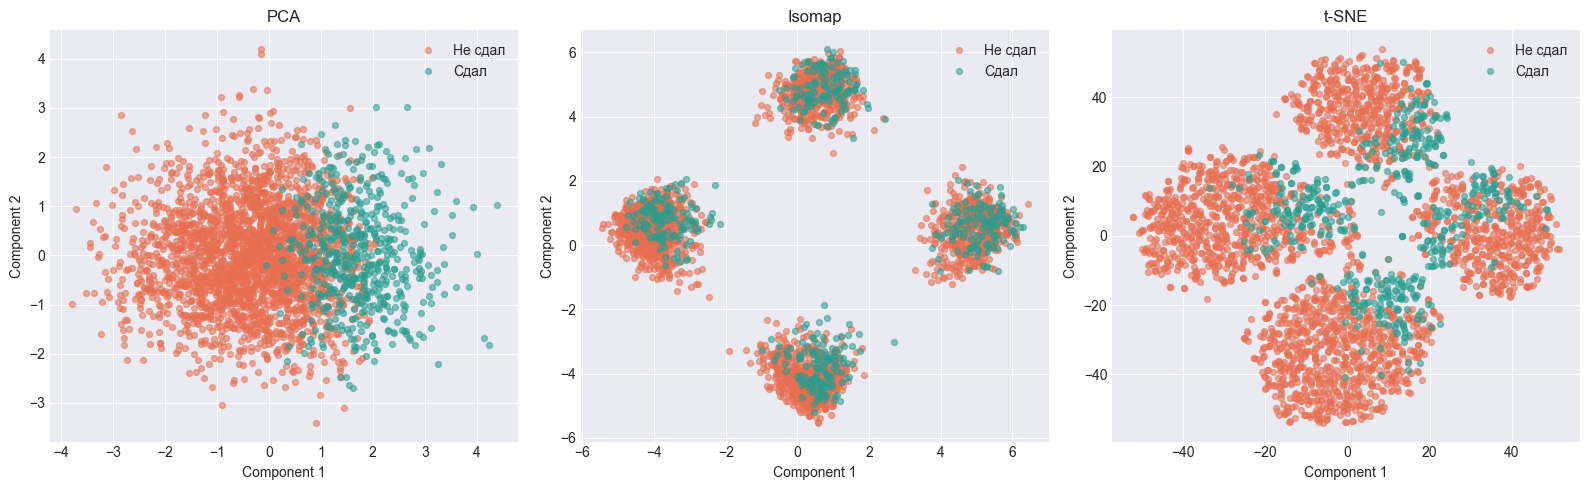

In [6]:
embedding_models = {
    "PCA": PCA(n_components=2, random_state=42),
    "Isomap": Isomap(n_neighbors=15, n_components=2),
    "t-SNE": TSNE(
        n_components=2,
        perplexity=40,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=42,
    ),
}

embeddings = {}
runtime_rows = []
for name, model in embedding_models.items():
    start = time.time()
    embeddings[name] = model.fit_transform(X)
    runtime = time.time() - start
    runtime_rows.append({"method": name, "runtime_sec": runtime})

runtime_df = pd.DataFrame(runtime_rows)
display(runtime_df.round(2))

pca_variance = embedding_models["PCA"].explained_variance_ratio_
print("PCA explained_variance_ratio_:", np.round(pca_variance, 4))
print("PCA cumulative variance:", round(float(pca_variance.sum()), 4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.ravel()
labels_map = {0: "Не сдал", 1: "Сдал"}
colors = {0: "#e76f51", 1: "#2a9d8f"}

for ax, (name, emb) in zip(axes, embeddings.items()):
    for label in [0, 1]:
        mask = y == label
        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            s=18,
            alpha=0.55,
            c=colors[label],
            label=labels_map[label],
        )
    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend()

plt.tight_layout()
plt.show()


PCA работает практически мгновенно и объясняет 21.68% дисперсии первыми двумя компонентами. Isomap занял 1.53 с, t-SNE 6.36 с. Нелинейные методы формируют более компактные облака, но по одной только картинке пока нельзя утверждать, что они лучше отражают успешность сдачи экзамена.


,DR,Algorithm,n_clusters,noise_share,silhouette,calinski_harabasz,davies_bouldin,ARI_passed_exam,AMI_passed_exam
6,Isomap,DBSCAN,4,0.0007,0.8291,29414.0654,0.2337,0.0079,0.0031
3,Isomap,KMeans,2,0.0000,0.5230,2815.4174,0.9920,0.0185,0.0050
4,Isomap,Agglomerative,2,0.0000,0.5230,2815.4174,0.9920,0.0185,0.0050
5,Isomap,GMM,2,0.0000,0.5230,2815.4174,0.9920,0.0185,0.0050
8,t-SNE,Agglomerative,2,0.0000,0.4111,2203.5076,1.0625,0.0184,0.0049
9,t-SNE,GMM,2,0.0000,0.4111,2203.5076,1.0625,0.0184,0.0049
7,t-SNE,KMeans,2,0.0000,0.4101,2215.7266,1.0652,0.0265,0.0105
2,PCA,GMM,2,0.0000,0.3456,1866.3625,1.1196,0.1974,0.2733
0,PCA,KMeans,2,0.0000,0.3454,1899.1274,1.1111,0.1679,0.2634
1,PCA,Agglomerative,2,0.0000,0.3167,1622.2061,1.1038,-0.0393,0.1527


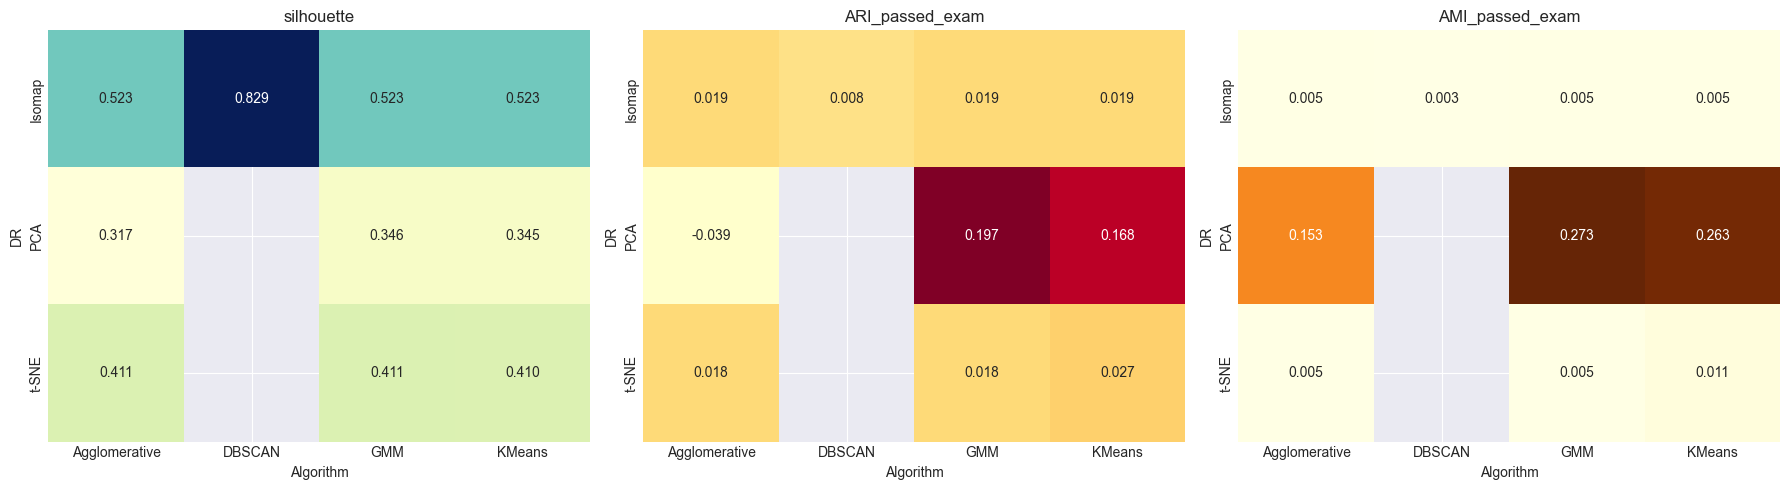

In [7]:
def sanitize_labels(labels: np.ndarray) -> np.ndarray:
    labels = labels.copy()
    if -1 in labels:
        valid = labels[labels != -1]
        fill_label = pd.Series(valid).mode().iat[0]
        labels[labels == -1] = fill_label
    return labels


def evaluate_solution(embedding_name: str, algo_name: str, labels: np.ndarray) -> dict | None:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return None

    labels_eval = sanitize_labels(labels)
    emb = embeddings[embedding_name]
    return {
        "DR": embedding_name,
        "Algorithm": algo_name,
        "n_clusters": n_clusters,
        "noise_share": (labels == -1).mean(),
        "silhouette": silhouette_score(emb, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(emb, labels_eval),
        "davies_bouldin": davies_bouldin_score(emb, labels_eval),
        "ARI_passed_exam": adjusted_rand_score(y, labels_eval),
        "AMI_passed_exam": adjusted_mutual_info_score(y, labels_eval),
    }


clustering_results = {}
metric_rows = []
dbscan_eps = {"PCA": 0.6, "Isomap": 0.8, "t-SNE": 1.8}

for name, emb in embeddings.items():
    clustering_results[name] = {
        "KMeans": KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(emb),
        "Agglomerative": AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(emb),
        "GMM": GaussianMixture(n_components=2, random_state=42).fit(emb).predict(emb),
        "DBSCAN": DBSCAN(eps=dbscan_eps[name], min_samples=25).fit_predict(emb),
    }

    for algo_name, labels in clustering_results[name].items():
        row = evaluate_solution(name, algo_name, labels)
        if row is not None:
            metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
display(
    metrics_df.sort_values(["silhouette", "ARI_passed_exam"], ascending=[False, False]).round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, cmap in zip(
    axes,
    ["silhouette", "ARI_passed_exam", "AMI_passed_exam"],
    ["YlGnBu", "YlOrRd", "YlOrBr"],
):
    pivot = metrics_df.pivot(index="DR", columns="Algorithm", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, cbar=False)
    ax.set_title(metric)

plt.tight_layout()
plt.show()


 По внутренним метрикам лидирует `Isomap + DBSCAN`: silhouette `0.829` и Davies-Bouldin `0.234`. Но его ARI относительно `passed_exam` почти нулевой: `0.008`. Лучшее внешнее согласование показывает `PCA + GMM`: ARI `0.197`, AMI `0.273` при silhouette `0.346`. Вывод важный: самые “красивые” кластеры по геометрии не обязаны быть самыми полезными для объяснения результата экзамена.


,DR,Algorithm,stability_ari_mean,stability_ari_min
0,PCA,KMeans,1.0000,1.0000
1,PCA,Agglomerative,1.0000,1.0000
3,Isomap,KMeans,1.0000,1.0000
4,Isomap,Agglomerative,1.0000,1.0000
6,Isomap,DBSCAN,1.0000,1.0000
7,t-SNE,KMeans,1.0000,1.0000
8,t-SNE,Agglomerative,1.0000,1.0000
2,PCA,GMM,0.9876,0.9841
9,t-SNE,GMM,0.3340,0.0010
5,Isomap,GMM,0.3337,0.0005


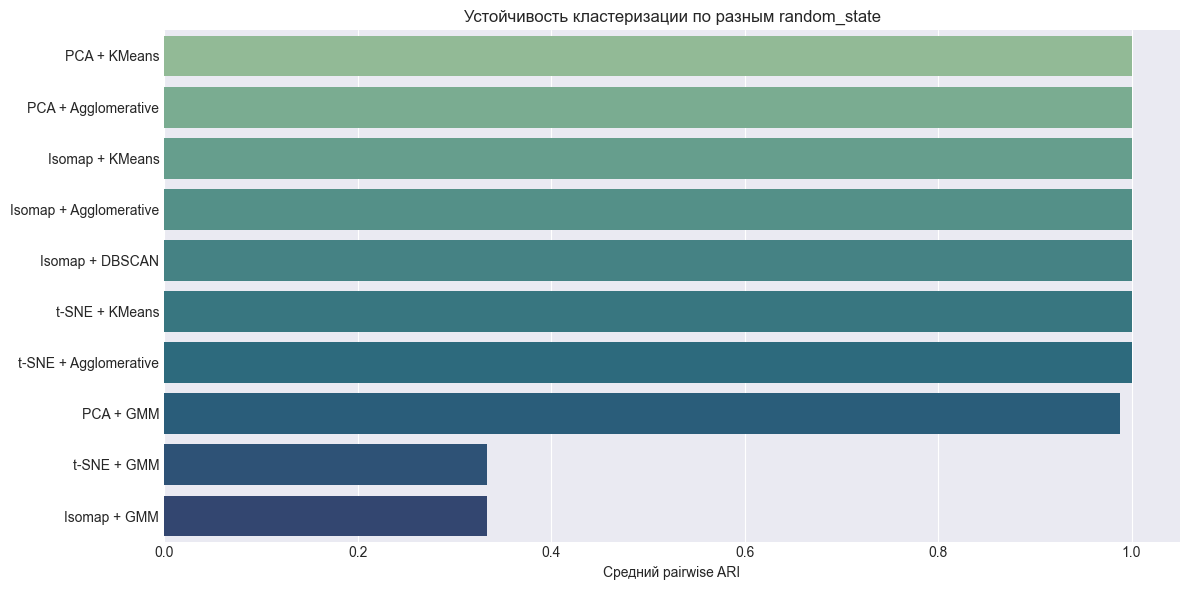

In [8]:
seed_list = [42, 52, 62]
stability_rows = []

def build_embedding_by_seed(method_name: str, seed: int) -> np.ndarray:
    if method_name == "PCA":
        return PCA(n_components=2, random_state=seed).fit_transform(X)
    if method_name == "Isomap":
        return Isomap(n_neighbors=15, n_components=2).fit_transform(X)
    if method_name == "t-SNE":
        return TSNE(
            n_components=2,
            perplexity=40,
            learning_rate="auto",
            init="pca",
            max_iter=1000,
            random_state=seed,
        ).fit_transform(X)
    raise ValueError(f"Unknown method: {method_name}")


for method_name in ["PCA", "Isomap", "t-SNE"]:
    emb_by_seed = {seed: build_embedding_by_seed(method_name, seed) for seed in seed_list}

    for algo_name in ["KMeans", "Agglomerative", "GMM", "DBSCAN"]:
        labels_runs = []
        for seed in seed_list:
            emb = emb_by_seed[seed]
            if algo_name == "KMeans":
                labels = KMeans(n_clusters=2, random_state=seed, n_init=20).fit_predict(emb)
            elif algo_name == "Agglomerative":
                labels = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(emb)
            elif algo_name == "GMM":
                labels = GaussianMixture(n_components=2, random_state=seed).fit(emb).predict(emb)
            else:
                labels = DBSCAN(eps=dbscan_eps[method_name], min_samples=25).fit_predict(emb)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters < 2:
                labels_runs = []
                break
            labels_runs.append(sanitize_labels(labels))

        if not labels_runs:
            continue

        pairwise_ari = []
        for i in range(len(labels_runs)):
            for j in range(i + 1, len(labels_runs)):
                pairwise_ari.append(adjusted_rand_score(labels_runs[i], labels_runs[j]))

        stability_rows.append(
            {
                "DR": method_name,
                "Algorithm": algo_name,
                "stability_ari_mean": np.mean(pairwise_ari),
                "stability_ari_min": np.min(pairwise_ari),
            }
        )

stability_df = pd.DataFrame(stability_rows).sort_values(
    ["stability_ari_mean", "stability_ari_min"], ascending=[False, False]
)
display(stability_df.round(4))

plt.figure(figsize=(12, 6))
plot_df = stability_df.copy()
plot_df["method_algo"] = plot_df["DR"] + " + " + plot_df["Algorithm"]
sns.barplot(data=plot_df, x="stability_ari_mean", y="method_algo", palette="crest")
plt.title("Устойчивость кластеризации по разным random_state")
plt.xlabel("Средний pairwise ARI")
plt.ylabel("")
plt.tight_layout()
plt.show()


Большинство комбинаций оказались полностью устойчивыми по `random_state`: их средний pairwise ARI равен 1.0. Даже `PCA + GMM` держится очень хорошо (`0.988`). Слабое место здесь  GMM после нелинейных embedding'ов: у `t-SNE + GMM` средняя устойчивость падает до `0.334`, а минимальная почти в ноль (`0.001`), то есть смесь Гауссиан становится чувствительна к инициализации в более сложной геометрии.


,size,final_exam_score,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,debugging_sessions_per_week,self_reported_confidence_python,passed_exam_rate,top_country,top_experience
cluster,,,,,,,,,,,
0,1646,31.76,5.96,59.61,1.49,39.52,4.79,4.66,0.0,Other,Unknown
1,1354,57.37,8.34,60.43,2.62,40.35,5.19,6.67,39.0,Brazil,Beginner


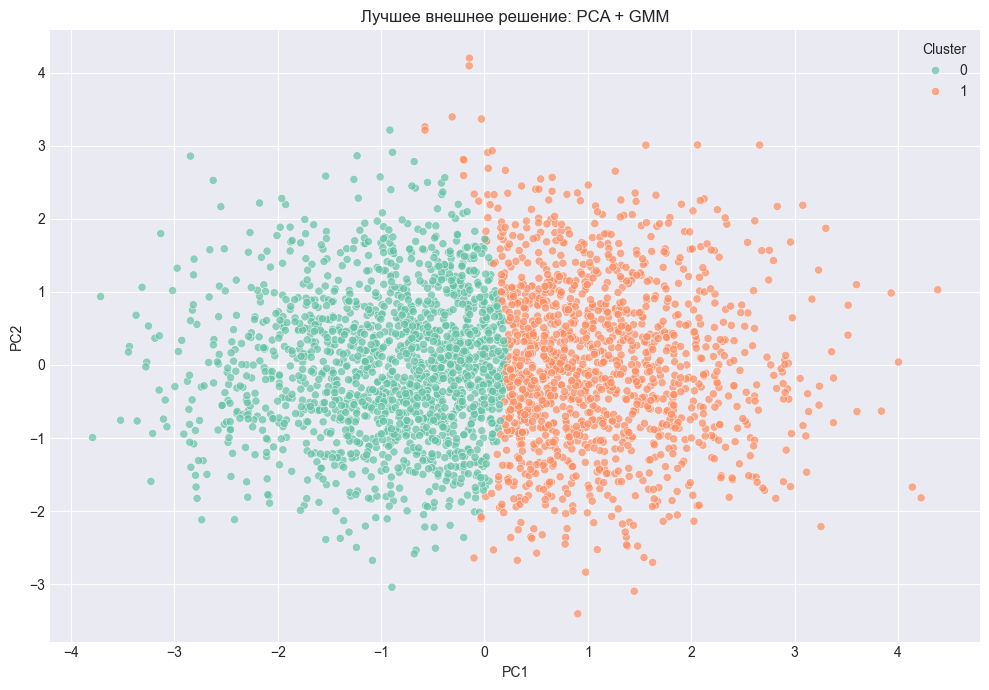

In [9]:
best_external_dr = "PCA"
best_external_algo = "GMM"
best_external_labels = clustering_results[best_external_dr][best_external_algo]
best_external_labels_eval = sanitize_labels(best_external_labels)

external_profile = df.copy()
external_profile["cluster"] = best_external_labels_eval

profile_external_df = (
    external_profile.groupby("cluster")
    .agg(
        size=("cluster", "size"),
        final_exam_score=("final_exam_score", "mean"),
        hours_spent_learning_per_week=("hours_spent_learning_per_week", "mean"),
        practice_problems_solved=("practice_problems_solved", "mean"),
        projects_completed=("projects_completed", "mean"),
        tutorial_videos_watched=("tutorial_videos_watched", "mean"),
        debugging_sessions_per_week=("debugging_sessions_per_week", "mean"),
        self_reported_confidence_python=("self_reported_confidence_python", "mean"),
        passed_exam_rate=("passed_exam", "mean"),
        top_country=("country", lambda s: s.mode().iat[0]),
        top_experience=("prior_programming_experience", lambda s: s.mode().iat[0]),
    )
    .round(2)
)
profile_external_df["passed_exam_rate"] = (profile_external_df["passed_exam_rate"] * 100).round(1)
display(profile_external_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embeddings["PCA"][:, 0],
    y=embeddings["PCA"][:, 1],
    hue=best_external_labels_eval,
    palette="Set2",
    s=35,
    alpha=0.7,
)
plt.title("Лучшее внешнее решение: PCA + GMM")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


 У лучшего внешнего решения видно два содержательных профиля. Кластер 0 включает 1646 студентов со средним баллом 31.76, 5.96 часов в неделю, 1.49 проекта и нулевой долей сдавших. Кластер 1 включает 1354 студентов со средним баллом 57.37, 8.34 часов, 2.62 проекта, уверенностью 6.67 и долей сдавших 39.0%. По сути это разделение на менее вовлеченную и более успешную учебную траекторию.


,size,final_exam_score,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,debugging_sessions_per_week,self_reported_confidence_python,passed_exam_rate,top_country,top_experience
cluster,,,,,,,,,,,
0,874,43.13,7.12,59.95,1.97,39.86,4.90,5.59,16.0,Germany,Unknown
1,924,40.73,7.12,59.81,2.01,39.85,4.93,5.55,14.0,Brazil,Unknown
2,582,44.90,6.84,60.40,2.12,40.22,4.99,5.54,21.0,Germany,Unknown
3,620,45.97,6.96,59.90,1.92,39.71,5.13,5.58,21.0,Brazil,Beginner


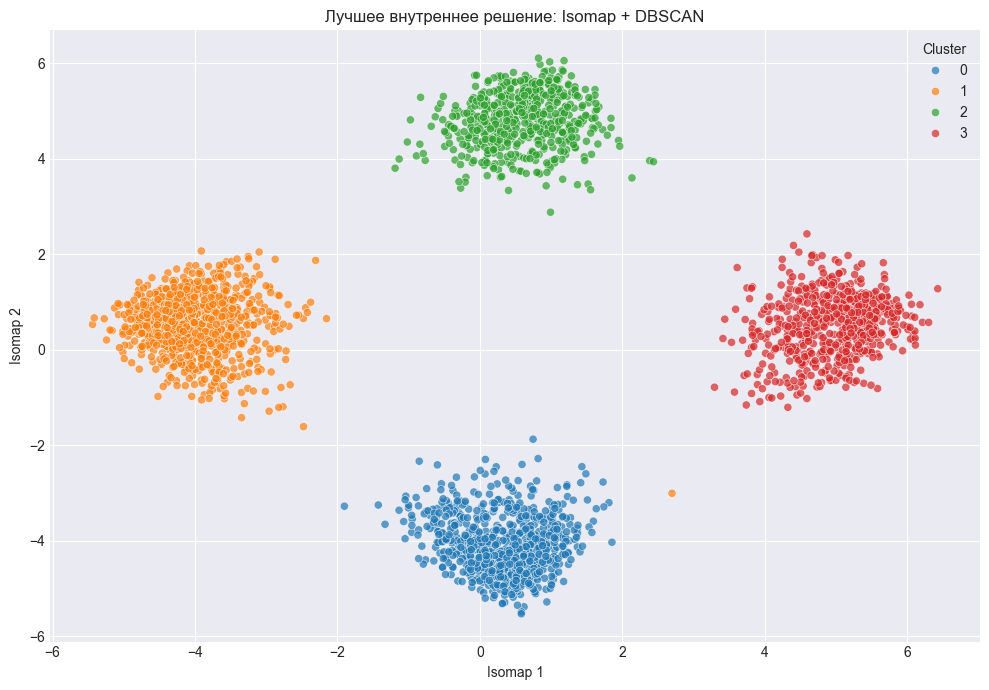

In [10]:
best_internal_dr = "Isomap"
best_internal_algo = "DBSCAN"
best_internal_labels_raw = clustering_results[best_internal_dr][best_internal_algo]
best_internal_labels_eval = sanitize_labels(best_internal_labels_raw)

internal_profile = df.copy()
internal_profile["cluster"] = best_internal_labels_eval

profile_internal_df = (
    internal_profile.groupby("cluster")
    .agg(
        size=("cluster", "size"),
        final_exam_score=("final_exam_score", "mean"),
        hours_spent_learning_per_week=("hours_spent_learning_per_week", "mean"),
        practice_problems_solved=("practice_problems_solved", "mean"),
        projects_completed=("projects_completed", "mean"),
        tutorial_videos_watched=("tutorial_videos_watched", "mean"),
        debugging_sessions_per_week=("debugging_sessions_per_week", "mean"),
        self_reported_confidence_python=("self_reported_confidence_python", "mean"),
        passed_exam_rate=("passed_exam", "mean"),
        top_country=("country", lambda s: s.mode().iat[0]),
        top_experience=("prior_programming_experience", lambda s: s.mode().iat[0]),
    )
    .round(2)
)
profile_internal_df["passed_exam_rate"] = (profile_internal_df["passed_exam_rate"] * 100).round(1)
display(profile_internal_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embeddings["Isomap"][:, 0],
    y=embeddings["Isomap"][:, 1],
    hue=best_internal_labels_eval,
    palette="tab10",
    s=35,
    alpha=0.7,
)
plt.title("Лучшее внутреннее решение: Isomap + DBSCAN")
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


 У `Isomap + DBSCAN` внутренняя геометрия отличная, но содержательно кластеры похожи друг на друга. Средний `final_exam_score` лежит в диапазоне от 40.73 до 45.97, а доля сдавших всего от 14.0% до 21.0%. Это хороший пример того, что высокий silhouette еще не гарантирует прикладную полезность кластеризации: метод красиво делит пространство, но почти не помогает объяснить исход экзамена.
